# Deep Learning Applications: Laboratory #1

In this first laboratory we will work relatively simple architectures to get a feel for working with Deep Models. This notebook is designed to work with PyTorch, but as I said in the introductory lecture: please feel free to use and experiment with whatever tools you like.

**Important Notes**:
1. Be sure to **document** all of your decisions, as well as your intermediate and final results. Make sure your conclusions and analyses are clearly presented. Don't make us dig into your code or walls of printed results to try to draw conclusions from your code.
2. If you use code from someone else (e.g. Github, Stack Overflow, ChatGPT, etc) you **must be transparent about it**. Document your sources and explain how you adapted any partial solutions to creat **your** solution.



## Exercise 1: Warming Up
In this series of exercises I want you to try to duplicate (on a small scale) the results of the ResNet paper:

> [Deep Residual Learning for Image Recognition](https://arxiv.org/abs/1512.03385), Kaiming He, Xiangyu Zhang, Shaoqing Ren, Jian Sun, CVPR 2016.

We will do this in steps using a Multilayer Perceptron on MNIST.

Recall that the main message of the ResNet paper is that **deeper** networks do not **guarantee** more reduction in training loss (or in validation accuracy). Below you will incrementally build a sequence of experiments to verify this for an MLP. A few guidelines:

+ I have provided some **starter** code at the beginning. **NONE** of this code should survive in your solutions. Not only is it **very** badly written, it is also written in my functional style that also obfuscates what it's doing (in part to **discourage** your reuse!). It's just to get you *started*.
+ These exercises ask you to compare **multiple** training runs, so it is **really** important that you factor this into your **pipeline**. Using [Tensorboard](https://pytorch.org/tutorials/recipes/recipes/tensorboard_with_pytorch.html) is a **very** good idea -- or, even better [Weights and Biases](https://wandb.ai/site).
+ You may work and submit your solutions in **groups of at most two**. Share your ideas with everyone, but the solutions you submit *must be your own*.

First some boilerplate to get you started, then on to the actual exercises!

### Preface: Some code to get you started

What follows is some **very simple** code for training an MLP on MNIST. The point of this code is to get you up and running (and to verify that your Python environment has all needed dependencies).

**Note**: As you read through my code and execute it, this would be a good time to think about *abstracting* **your** model definition, and training and evaluation pipelines in order to make it easier to compare performance of different models.

## Imports

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import torch
from torch.utils.data import DataLoader
from torchvision.datasets import MNIST
from torch.utils.data import Subset
import torchvision.transforms as transforms
from torchvision.datasets import CIFAR10
import copy
import torch.nn as nn
import wandb
from tqdm.auto import tqdm
import pandas as pd
from torchvision.models import resnet18, ResNet18_Weights
from torchvision.datasets import Imagenette
from torchvision.models.resnet import BasicBlock

# seed for reproducibility
np.random.seed(42)
torch.manual_seed(42)

device = 'cuda' if torch.cuda.is_available() else 'cpu'
print(f'Device: {device}')

Device: cuda


## Import dataset

In [2]:
CIFAR10_MEAN = (0.4914, 0.4822, 0.4465)
CIFAR10_STD = (0.2470, 0.2435, 0.2616)

def get_mnist(batch_size=128, val_set_size=5000, seed=42, num_workers=2, show=False):
    """(train_loader, val_loader, test_loader) di MNIST. show=True stampa le dimensioni e mostra esempi."""
    tf = transforms.Compose([transforms.ToTensor(), transforms.Normalize((0.1307,), (0.3081,))])
    train_full = MNIST("./data", train=True, download=True, transform=tf)
    ds_test = MNIST("./data", train=False, download=True, transform=tf)

    perm = np.random.default_rng(seed).permutation(len(train_full)).tolist()  # split riproducibile
    ds_train, ds_val = Subset(train_full, perm[val_set_size:]), Subset(train_full, perm[:val_set_size])

    if show:
        print(f"Train: {len(ds_train)}, Val: {len(ds_val)}, Test: {len(ds_test)} "
              f"| shape immagine: {tuple(ds_train[0][0].shape)}")
        fig, axes = plt.subplots(1, 10, figsize=(16, 2))
        for i, ax in enumerate(axes):
            img, label = ds_train[i]
            ax.imshow(img.squeeze(), cmap="gray")
            ax.set_title(str(label))
            ax.axis("off")
        plt.suptitle("MNIST Examples")
        plt.show()

    g = torch.Generator().manual_seed(seed)
    kw = dict(batch_size=batch_size, num_workers=num_workers,
              pin_memory=torch.cuda.is_available(), persistent_workers=num_workers > 0)
    return (DataLoader(ds_train, shuffle=True, generator=g, **kw),
            DataLoader(ds_val, **kw), DataLoader(ds_test, **kw))


def get_cifar10(batch_size=128, val_set_size=5000, seed=42, augmentation=True, num_workers=2, show=False):
    """
    (train_loader, val_loader, test_loader) di CIFAR-10. show=True stampa le dimensioni e mostra esempi.
    """
    tf = transforms.Compose([transforms.ToTensor(), transforms.Normalize(CIFAR10_MEAN, CIFAR10_STD)])
    tf_train = transforms.Compose([transforms.RandomCrop(32, padding=4),
                                   transforms.RandomHorizontalFlip(), tf]) if augmentation else tf

    train_full = CIFAR10("./data", train=True, download=True, transform=tf_train)
    val_full = CIFAR10("./data", train=True, download=True, transform=tf)
    ds_test = CIFAR10("./data", train=False, download=True, transform=tf)

    perm = np.random.default_rng(seed).permutation(len(train_full)).tolist()  # split riproducibile
    ds_train, ds_val = Subset(train_full, perm[val_set_size:]), Subset(val_full, perm[:val_set_size])

    if show:
        print(f"Train: {len(ds_train)}, Val: {len(ds_val)}, Test: {len(ds_test)} "
              f"| shape immagine: {tuple(ds_train[0][0].shape)}")
        mean, std = torch.tensor(CIFAR10_MEAN).view(3, 1, 1), torch.tensor(CIFAR10_STD).view(3, 1, 1)
        fig, axes = plt.subplots(1, 10, figsize=(16, 2))
        for i, ax in enumerate(axes):
            img, label = ds_train[i]
            ax.imshow((img * std + mean).clamp(0, 1).permute(1, 2, 0))  # de-normalizzazione, (C,H,W) -> (H,W,C)
            ax.set_title(train_full.classes[label])
            ax.axis("off")
        plt.suptitle("CIFAR-10 Examples")
        plt.show()

    g = torch.Generator().manual_seed(seed)  # ordine dei batch di training riproducibile
    kw = dict(batch_size=batch_size, num_workers=num_workers,
              pin_memory=torch.cuda.is_available(), persistent_workers=num_workers > 0)
    return (DataLoader(ds_train, shuffle=True, generator=g, **kw),
            DataLoader(ds_val, **kw), DataLoader(ds_test, **kw))

### Exercise 1.1: A baseline MLP

Implement a *simple* Multilayer Perceptron to classify the 10 digits of MNIST (e.g. two *narrow* layers). Use my code above as inspiration, but implement your own training pipeline -- you will need it later. Train this model to convergence, monitoring (at least) the loss and accuracy on the training and validation sets for every epoch. Below I include a basic implementation to get you started -- remember that you should write your *own* pipeline!

**Note**: This would be a good time to think about *abstracting* your model definition, and training and evaluation pipelines in order to make it easier to compare performance of different models.

**Important**: Given the *many* runs you will need to do, and the need to *compare* performance between them, this would **also** be a great point to study how **Tensorboard** or **Weights and Biases** can be used for performance monitoring.

unziona, risultati su wandb, all'aumentare della profondità non aumentano le prestazioni

Train: 55000, Val: 5000, Test: 10000 | shape immagine: (1, 28, 28)


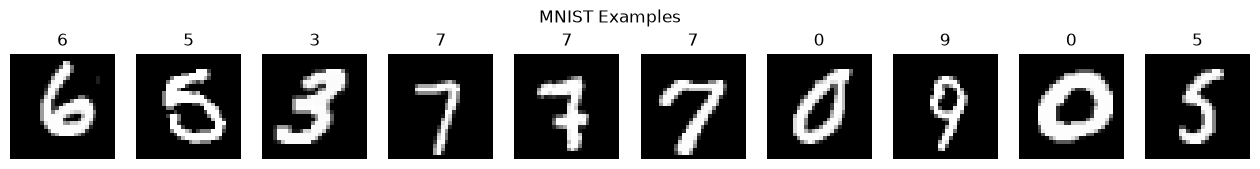

wandb: [wandb.login()] Loaded credentials for https://api.wandb.ai from /home/filo/.netrc.
wandb: W&B API key is configured. Use `wandb login --relogin` to force relogin


True

In [3]:
train_loader, val_loader, test_loader = get_mnist(show=True)
wandb.login()

In [4]:
# Modello e training
class MLP(nn.Module):
    def __init__(self, input_dim=28 * 28, hidden_dim=64, depth=1, num_classes=10):
        super().__init__()
        layers = [nn.Flatten(), nn.Linear(input_dim, hidden_dim), nn.ReLU()]
        for _ in range(depth):
            layers += [nn.Linear(hidden_dim, hidden_dim), nn.ReLU()]
        layers.append(nn.Linear(hidden_dim, num_classes))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


def run_epoch(model, loader, loss_fn, device, optimizer=None, desc=""):

    training = optimizer is not None
    model.train(training)
    total_loss, correct, n = 0.0, 0, 0
    with torch.set_grad_enabled(training):
        for x, y in tqdm(loader, desc=desc, leave=False):
            x, y = x.to(device), y.to(device)
            logits = model(x)
            loss = loss_fn(logits, y)
            if training:
                optimizer.zero_grad()
                loss.backward()
                optimizer.step()
            total_loss += loss.item() * y.size(0)  # media pesata
            correct += (logits.argmax(dim=1) == y).sum().item()
            n += y.size(0)
    return total_loss / n, correct / n


def evaluate(model, loader, device, loss_fn=nn.CrossEntropyLoss()):
    return run_epoch(model, loader, loss_fn, device, desc="Eval")


def train_model(model, train_loader, val_loader, device, config, run_name=None,
                project="dla-lab1", log_wandb=True, test_loader=None):

    model.to(device)
    epochs = config["epochs"]
    loss_fn = nn.CrossEntropyLoss()

    optimizer = getattr(torch.optim, config["optimizer"])(model.parameters(), lr=config["lr"])
    scheduler = (torch.optim.lr_scheduler.CosineAnnealingLR(optimizer, T_max=epochs)
                 if config["use_scheduler"] else None)
    run = wandb.init(project=project, name=run_name, config=config) if log_wandb else None

    history = {"train_loss": [], "train_acc": [], "val_loss": [], "val_acc": []}
    best_acc, best_state = -1.0, None

    for epoch in range(1, epochs + 1):
        tr_loss, tr_acc = run_epoch(model, train_loader, loss_fn, device, optimizer, desc=f"Epoch {epoch}")
        val_loss, val_acc = run_epoch(model, val_loader, loss_fn, device, desc="Val")
        if scheduler:
            scheduler.step()

        for key, value in zip(history, (tr_loss, tr_acc, val_loss, val_acc)):
            history[key].append(value)
        if run:
            run.log({"epoch": epoch, "train/loss": tr_loss, "train/accuracy": tr_acc,
                     "val/loss": val_loss, "val/accuracy": val_acc})
        if val_acc > best_acc:
            best_acc, best_state = val_acc, copy.deepcopy(model.state_dict())

    model.load_state_dict(best_state)
    if test_loader is not None:
        history["test_loss"], history["test_acc"] = evaluate(model, test_loader, device)
    if run:
        run.summary["best_val_accuracy"] = best_acc
        if test_loader is not None:
            run.summary["test/loss"] = history["test_loss"]
            run.summary["test/accuracy"] = history["test_acc"]
        run.finish()
    print(f"[{run_name}] best val acc: {best_acc:.4f} (epoch {history['val_acc'].index(best_acc) + 1})")
    return history


In [5]:
# Main
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Device: {device}" + (f" ({torch.cuda.get_device_name(0)})" if device.type == "cuda" else ""))

MODELS = {"MLP": MLP}
DATASETS = {"MNIST": get_mnist}

config = {
    "architecture": "MLP",
    "dataset": "MNIST",
    "optimizer": "Adam",
    "epochs": 20,
    "lr": 1e-3,
    "batch_size": 128,
    "val_set_size": 5000,
    "use_scheduler": False,
    "seed": 42,
}
results = {}

for depth in [1, 2, 4, 8, 16]:
    for hidden_dim in [64]:
        run_config = {**config, "depth": depth, "hidden_dim": hidden_dim}
        name = f"mlp_d{depth}_h{hidden_dim}"

        train_loader, val_loader, test_loader = DATASETS[run_config["dataset"]](
            batch_size=run_config["batch_size"],
            val_set_size=run_config["val_set_size"],
            seed=run_config["seed"],
        )
        torch.manual_seed(run_config["seed"])
        model = MODELS[run_config["architecture"]](
            hidden_dim=run_config["hidden_dim"],
            depth=run_config["depth"],
        )
        history = train_model(model, train_loader, val_loader, device, run_config, run_name=name, test_loader=test_loader)
        results[name] = (model, history, run_config)

Device: cuda (NVIDIA GeForce RTX 2080)


wandb: Currently logged in as: filippozaccari (filippozaccari-unifi) to https://api.wandb.ai. Use `wandb login --relogin` to force relogin


Epoch 1:   0%|          | 0/430 [00:00<?, ?it/s]

Val:   0%|          | 0/40 [00:00<?, ?it/s]

Epoch 2:   0%|          | 0/430 [00:00<?, ?it/s]

...

Epoch 20:   0%|          | 0/430 [00:00<?, ?it/s]

Val:   0%|          | 0/40 [00:00<?, ?it/s]

Eval:   0%|          | 0/79 [00:00<?, ?it/s]

epoch,▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
train/accuracy,▁▆▇▇▇████▇██████████
train/loss,█▃▂▂▂▁▁▂▁▂▁▁▁▁▁▁▁▁▁▁
val/accuracy,▂▆▇▇▇▇█▇██████████▁█
val/loss,▆▃▂▂▂▂▂▂▁▂▂▁▁▁▁▁▁▁█▁
best_val_accuracy,0.9618
epoch,20
test/accuracy,0.9677
test/loss,0.14504
train/accuracy,0.97249
train/loss,0.1107


[mlp_d16_h64] best val acc: 0.9618 (epoch 17)


### FUNZIONA
MLP normale più è profondo e più overfitta, la loss non va giù, la accuracy non migliora. Con residual connection invece la loss scende e la accuracy sale, anche con depth più profondi

### Exercise 1.2: Adding Residual Connections

Implement a variant of your parameterized MLP network to support residual connections. Your network should be defined as a composition of residual MLP blocks that have one or more linear layers and add a skip connection from the block input to the output of the final linear layer.

Compare the performance (in training/validation loss and test accuracy) of your MLP and ResidualMLP for a range of depths. Verify that deeper networks with residual connections are easier to train than a network of the same depth without residual connections.

For extra style points: See if you can explain by analyzing the gradient magnitudes on a single training batch *why* this is the case.

In [6]:
class ResidualMLPBlock(nn.Module):
    def __init__(self, dim, num_layers=2):
        super().__init__()
        layers = []
        for i in range(num_layers):
            layers.append(nn.Linear(dim, dim))
            if i < num_layers - 1:
                layers.append(nn.ReLU())
        self.f = nn.Sequential(*layers)
        self.act = nn.ReLU()

    def forward(self, x):
        return self.act(x + self.f(x))


class ResidualMLP(nn.Module):
    def __init__(self, input_dim=28 * 28, hidden_dim=64, depth=2, num_classes=10, layers_per_block=2):
        super().__init__()
        layers = [nn.Flatten(), nn.Linear(input_dim, hidden_dim), nn.ReLU()]
        layers += [ResidualMLPBlock(hidden_dim, layers_per_block) for _ in range(depth // layers_per_block)]
        layers.append(nn.Linear(hidden_dim, num_classes))
        self.net = nn.Sequential(*layers)

    def forward(self, x):
        return self.net(x)


MODELS["ResidualMLP"] = ResidualMLP


In [7]:
config_12 = {
    "dataset": "MNIST",
    "optimizer": "Adam",
    "epochs": 20,
    "lr": 1e-3,
    "batch_size": 128,
    "val_set_size": 5000,
    "use_scheduler": False,
    "seed": 42,
    "hidden_dim": 64,
    "layers_per_block": 2,
}
depths_12 = [2, 4, 8, 16, 32]
results_12 = {}

for arch in ["MLP", "ResidualMLP"]:
    for depth in depths_12:
        run_config = {**config_12, "architecture": arch, "depth": depth}
        model_kwargs = {"hidden_dim": run_config["hidden_dim"], "depth": depth}
        if arch == "ResidualMLP":
            model_kwargs["layers_per_block"] = run_config["layers_per_block"]
        else:
            del run_config["layers_per_block"]
        name = f"{arch}_d{depth}"

        train_loader, val_loader, test_loader = DATASETS[run_config["dataset"]](
            batch_size=run_config["batch_size"],
            val_set_size=run_config["val_set_size"],
            seed=run_config["seed"],
        )
        torch.manual_seed(run_config["seed"])
        model = MODELS[arch](**model_kwargs)
        history = train_model(model, train_loader, val_loader, device, run_config, run_name=name,
                              project="dla-lab1-es1.2", test_loader=test_loader)
        results_12[name] = (model, history, run_config)


Epoch 1:   0%|          | 0/430 [00:00<?, ?it/s]

Val:   0%|          | 0/40 [00:00<?, ?it/s]

Epoch 2:   0%|          | 0/430 [00:00<?, ?it/s]

Val:   0%|          | 0/40 [00:00<?, ?it/s]

Epoch 3:   0%|          | 0/430 [00:00<?, ?it/s]

...

Epoch 20:   0%|          | 0/430 [00:00<?, ?it/s]

Val:   0%|          | 0/40 [00:00<?, ?it/s]

Eval:   0%|          | 0/79 [00:00<?, ?it/s]

epoch,▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
train/accuracy,▁▅▆▆▇▇▇▇▇▇██████████
train/loss,█▄▃▃▂▂▂▂▂▂▁▁▁▁▁▁▁▁▁▁
val/accuracy,▁▃▄▆▆▇▇▆▇▇▆▇▇▇▇▇▇██▇
val/loss,█▅▃▂▂▁▁▂▁▁▂▁▁▁▃▃▂▃▂▅
best_val_accuracy,0.9768
epoch,20
test/accuracy,0.9765
test/loss,0.10791
train/accuracy,0.99525
train/loss,0.01452


[ResidualMLP_d32] best val acc: 0.9768 (epoch 18)


### Gradient analysis  (da capire e da provare in fondo dopo aver finito i lab)

,iniziale,post-training,iniziale,post-training
,MLP,MLP,ResidualMLP,ResidualMLP
2,1.069713e+00,1.450218e+00,1.032360,2.240692
4,5.065596e-01,2.859064e+00,0.832075,2.389019
8,1.473759e-02,5.015036e+00,0.673261,2.345820
16,1.629873e-05,5.792586e+00,0.639246,5.808786
32,6.350325e-12,6.201433e-13,0.421922,13.990536


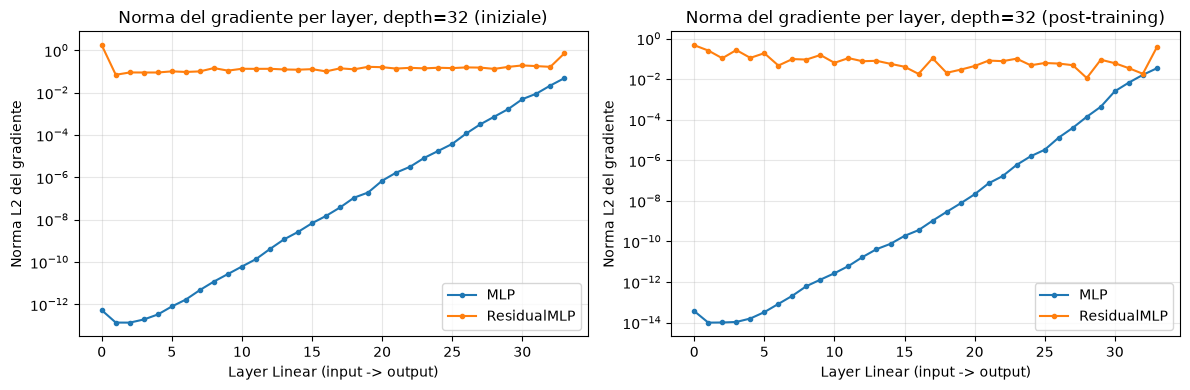

In [8]:
def grad_norms_per_layer(model, x, y):
    model.zero_grad()
    nn.functional.cross_entropy(model(x), y).backward()  # solo gradienti: i pesi non vengono aggiornati
    return [m.weight.grad.norm().item() for m in model.modules() if isinstance(m, nn.Linear)]


train_loader = get_mnist(batch_size=config_12["batch_size"], val_set_size=config_12["val_set_size"],
                         seed=config_12["seed"])[0]
x, y = (t.to(device) for t in next(iter(train_loader)))

grad_norms = {}
for trained_model, _, cfg in results_12.values():
    torch.manual_seed(cfg["seed"])
    init_model = MODELS[cfg["architecture"]](
        **{k: cfg[k] for k in ("hidden_dim", "depth", "layers_per_block") if k in cfg}).to(device)
    for stage, model in [("iniziale", init_model), ("post-training", trained_model)]:
        grad_norms[(cfg["architecture"], cfg["depth"], stage)] = grad_norms_per_layer(model, x, y)

ratios = pd.Series({k: norms[1] / norms[-2] for k, norms in grad_norms.items()}).unstack([2, 0])
display(ratios)

# Norme layer per layer per le reti piu' profonde
d = max(depths_12)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
for ax, stage in zip(axes, ["iniziale", "post-training"]):
    for arch in ["MLP", "ResidualMLP"]:
        ax.plot(grad_norms[(arch, d, stage)], marker="o", markersize=3, label=arch)
    ax.set(title=f"Norma del gradiente per layer, depth={d} ({stage})",
           xlabel="Layer Linear (input -> output)", ylabel="Norma L2 del gradiente", yscale="log")
    ax.grid(True, which="both", alpha=0.3)
    ax.legend()
plt.tight_layout()
plt.show()

### Exercise 1.3: Rinse and Repeat (but with a CNN)

Repeat the verification you did above, but with **Convolutional** Neural Networks. If you were careful about abstracting your model and training code, this should be a simple exercise. Show that **deeper** CNNs *without* residual connections do not always work better and **even deeper** ones *with* residual connections.

**Hint**: You probably should do this exercise using CIFAR-10, since MNIST is *very* easy (at least up to about 99% accuracy).

**Tip**: Feel free to reuse the ResNet building blocks defined in `torchvision.models.resnet` (e.g. [BasicBlock](https://github.com/pytorch/vision/blob/main/torchvision/models/resnet.py#L59) which handles the cascade of 3x3 convolutions, skip connections, and optional downsampling). This is an excellent exercise in code diving. 

**Spoiler**: Depending on the optional exercises you plan to do below, you should think *very* carefully about the architectures of your CNNs here (so you can reuse them!).

### FUNZIONA
Anche le CNN se si va troppo in profondità accusano il problema del vanishing gradient, e la loss non scende e la accuracy non sale. Con le residual connection invece la loss scende e la accuracy sale anche con depth più profondi.

In [9]:
class PlainBlock(nn.Module):
    def __init__(self, inplanes, planes, stride=1, downsample=None):
        super().__init__()
        self.f = nn.Sequential(
            nn.Conv2d(inplanes, planes, 3, stride, 1, bias=False), nn.BatchNorm2d(planes), nn.ReLU(inplace=True),
            nn.Conv2d(planes, planes, 3, 1, 1, bias=False), nn.BatchNorm2d(planes), nn.ReLU(inplace=True),
        )

    def forward(self, x):
        return self.f(x)


class CIFARNet(nn.Module):
    def __init__(self, block, depth=1, base_channels=16, num_classes=10):
        super().__init__()
        c = base_channels
        self.stem = nn.Sequential(nn.Conv2d(3, c, 3, 1, 1, bias=False), nn.BatchNorm2d(c), nn.ReLU(inplace=True))
        layers, in_ch = [], c
        for out_ch, stride in [(c, 1), (2 * c, 2), (4 * c, 2)]:
            downsample = None if (stride == 1 and in_ch == out_ch) else nn.Sequential(
                nn.Conv2d(in_ch, out_ch, 1, stride, bias=False), nn.BatchNorm2d(out_ch))
            layers.append(block(in_ch, out_ch, stride, downsample))
            layers += [block(out_ch, out_ch) for _ in range(depth - 1)]
            in_ch = out_ch
        self.stages = nn.Sequential(*layers)
        self.fc = nn.Linear(4 * c, num_classes)

    def feature_maps(self, x):
        return self.stages(self.stem(x))

    def forward(self, x):
        return self.fc(self.feature_maps(x).mean(dim=(2, 3)))


MODELS["PlainCNN"] = lambda **kw: CIFARNet(PlainBlock, **kw)
MODELS["ResidualCNN"] = lambda **kw: CIFARNet(BasicBlock, **kw)
DATASETS["CIFAR-10"] = get_cifar10


In [10]:
config_13 = {
    "dataset": "CIFAR-10",
    "augmentation": True,
    "optimizer": "Adam",
    "epochs": 20,
    "lr": 1e-3,
    "batch_size": 128,
    "val_set_size": 5000,
    "use_scheduler": True,
    "seed": 42,
    "base_channels": 16,
}
depths_13 = [1, 2, 4, 8, 16]
results_13 = {}

for arch in ["PlainCNN", "ResidualCNN"]:
    for depth in depths_13:
        run_config = {**config_13, "architecture": arch, "depth": depth, "n_layers": 6 * depth + 2}
        name = f"{arch}_d{depth}"

        # Loader e pesi ricreati con lo stesso seed: ogni run parte dalle stesse condizioni
        train_loader, val_loader, test_loader = DATASETS[run_config["dataset"]](
            batch_size=run_config["batch_size"],
            val_set_size=run_config["val_set_size"],
            seed=run_config["seed"],
            augmentation=run_config["augmentation"],
        )
        torch.manual_seed(run_config["seed"])
        model = MODELS[arch](depth=depth, base_channels=run_config["base_channels"])
        run_config["num_params"] = sum(p.numel() for p in model.parameters())

        history = train_model(model, train_loader, val_loader, device, run_config, run_name=name,
                              project="dla-lab1-es1.3", test_loader=test_loader)
        results_13[name] = (model, history, run_config)


Epoch 1:   0%|          | 0/352 [00:00<?, ?it/s]

Val:   0%|          | 0/40 [00:00<?, ?it/s]

Epoch 2:   0%|          | 0/352 [00:00<?, ?it/s]

Val:   0%|          | 0/40 [00:00<?, ?it/s]

Epoch 3:   0%|          | 0/352 [00:00<?, ?it/s]

...

Epoch 20:   0%|          | 0/352 [00:00<?, ?it/s]

Val:   0%|          | 0/40 [00:00<?, ?it/s]

Eval:   0%|          | 0/79 [00:00<?, ?it/s]

epoch,▁▁▂▂▂▃▃▄▄▄▅▅▅▆▆▇▇▇██
train/accuracy,▁▃▄▅▅▆▆▆▇▇▇▇▇▇██████
train/loss,█▆▅▄▄▃▃▃▂▂▂▂▂▂▁▁▁▁▁▁
val/accuracy,▁▄▃▅▅▆▆▆▇▇▇▇████████
val/loss,█▅▆▄▄▃▄▃▂▂▂▁▁▁▁▁▁▁▁▁
best_val_accuracy,0.866
epoch,20
test/accuracy,0.8612
test/loss,0.44153
train/accuracy,0.90953
train/loss,0.25712


[ResidualCNN_d16] best val acc: 0.8660 (epoch 19)


final_train_loss             test_acc             num_params  \
architecture           PlainCNN ResidualCNN PlainCNN ResidualCNN   PlainCNN   
depth n_layers                                                                
1     8                0.555471    0.573486   0.7912      0.7853    75290.0   
2     14               0.359897    0.359519   0.8416      0.8477   172506.0   
4     26               0.474306    0.286929   0.8101      0.8628   366938.0   
8     50               0.792775    0.263747   0.6964      0.8637   755802.0   
16    98               2.119688    0.257120   0.2118      0.8612  1533530.0   

                            
architecture   ResidualCNN  
depth n_layers              
1     8            78042.0  
2     14          175258.0  
4     26          369690.0  
8     50          758554.0  
16    98         1536282.0

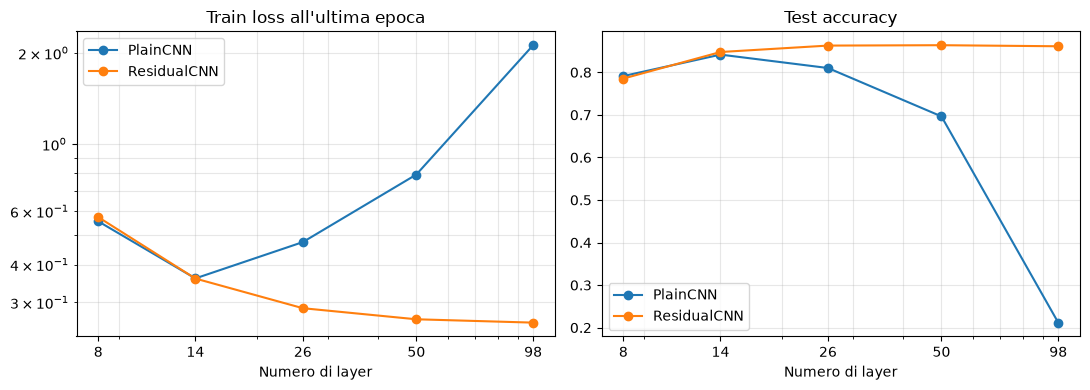

In [11]:
summary_13 = pd.DataFrame([
    {"architecture": c["architecture"], "depth": c["depth"], "n_layers": c["n_layers"],
     "num_params": c["num_params"], "final_train_loss": h["train_loss"][-1], "test_acc": h["test_acc"]}
    for _, h, c in results_13.values()
])
display(summary_13.pivot(index=["depth", "n_layers"], columns="architecture",
                         values=["final_train_loss", "test_acc", "num_params"]))

fig, axes = plt.subplots(1, 2, figsize=(11, 4))
for ax, metric, title in zip(axes, ["final_train_loss", "test_acc"], ["Train loss all'ultima epoca", "Test accuracy"]):
    for arch, df in summary_13.groupby("architecture"):
        ax.plot(df["n_layers"], df[metric], marker="o", label=arch)
    ax.set(title=title, xlabel="Numero di layer", xscale="log")
    ax.set_xticks(summary_13["n_layers"].unique(), labels=summary_13["n_layers"].unique())
    ax.grid(True, which="both", alpha=0.3)
    ax.legend()
axes[0].set_yscale("log")
plt.tight_layout()
plt.show()


-----
## Exercise 2: Choose at Least One

Below are **three** exercises that ask you to deepen your understanding of Deep Networks for visual recognition. You must choose **at least one** of the below for your final submission -- feel free to do **more**, but at least **ONE** you must submit. Each exercise is designed to require you to dig your hands **deep** into the guts of your models in order to do new and interesting things.

**Note**: These exercises are designed to use your small, custom CNNs and small datasets. This is to keep training times reasonable. If you have a decent GPU, feel free to use pretrained ResNets and larger datasets (e.g. the [Imagenette](https://pytorch.org/vision/0.20/generated/torchvision.datasets.Imagenette.html#torchvision.datasets.Imagenette) dataset at 160px).

### Exercise 2.1: *Fine-tune* a pre-trained model
Train one of your residual CNN models from Exercise 1.3 on CIFAR-10. Then:
1. Use the pre-trained model as a **feature extractor** (i.e. to extract the feature activations of the layer input into the classifier) on CIFAR-100. Use a **classical** approach (e.g. Linear SVM, K-Nearest Neighbor, or Bayesian Generative Classifier) from scikit-learn to establish a **stable baseline** performance on CIFAR-100 using the features extracted using your CNN.
2. Fine-tune your CNN on the CIFAR-100 training set and compare with your stable baseline. Experiment with different strategies:
    - Unfreeze some of the earlier layers for fine-tuning.
    - Test different optimizers (Adam, SGD, etc.).

Each of these steps will require you to modify your model definition in some way. For 1, you will need to return the activations of the last fully-connected layer (or the global average pooling layer). For 2, you will need to replace the original, 10-class classifier with a new, randomly-initialized 100-class classifier.

In [ ]:
# Your code here.

### Exercise 2.2: *Distill* the knowledge from a large model into a smaller one
In this exercise you will see if you can derive a *small* model that performs comparably to a larger one on CIFAR-10. To do this, you will use [Knowledge Distillation](https://arxiv.org/abs/1503.02531):

> Geoffrey Hinton, Oriol Vinyals, and Jeff Dean. Distilling the Knowledge in a Neural Network, NeurIPS 2015.

To do this:
1. Train one of your best-performing CNNs on CIFAR-10 from Exercise 1.3 above. This will be your **teacher** model.
2. Define a *smaller* variant with about half the number of parameters (change the width and/or depth of the network). Train it on CIFAR-10 and verify that it performs *worse* than your **teacher**. This small network will be your **student** model.
3. Train the **student** using a combination of **hard labels** from the CIFAR-10 training set (cross entropy loss) and **soft labels** from predictions of the **teacher** (Kulback-Leibler loss between teacher and student).

Try to optimize training parameters in order to maximize the performance of the student. It should at least outperform the student trained only on hard labels in Setp 2.

**Tip**: You can save the predictions of the trained teacher network on the training set and adapt your dataloader to provide them together with hard labels. This will **greatly** speed up training compared to performing a forward pass through the teacher for each batch of training.

In [ ]:
# Your code here.

### Exercise 2.3: *Explain* the predictions of a CNN

Use the CNN model you trained in Exercise 1.3 and implement [*Class Activation Maps*](http://cnnlocalization.csail.mit.edu/#:~:text=A%20class%20activation%20map%20for,decision%20made%20by%20the%20CNN.):

> B. Zhou, A. Khosla, A. Lapedriza, A. Oliva, and A. Torralba. Learning Deep Features for Discriminative Localization. CVPR'16 (arXiv:1512.04150, 2015).

Use your CNN implementation to demonstrate how your trained CNN *attends* to specific image features to recognize *specific* classes. Try your implementation out using a pre-trained ResNet-18 model and some images from the [Imagenette](https://pytorch.org/vision/0.20/generated/torchvision.datasets.Imagenette.html#torchvision.datasets.Imagenette) dataset -- I suggest you start with the low resolution version of images at 160px.

In [12]:
def compute_cam(feature_fn, fc, images):
    with torch.no_grad():
        fmaps = feature_fn(images)
        preds = fc(fmaps.mean(dim=(2, 3))).argmax(dim=1)
        weights = fc.weight[preds]
        cams = torch.einsum("bkhw,bk->bhw", fmaps, weights).clamp(min=0)
        cams = cams - cams.amin(dim=(1, 2), keepdim=True)
        cams = cams / (cams.amax(dim=(1, 2), keepdim=True) + 1e-8)
        cams = nn.functional.interpolate(cams[:, None], size=images.shape[-2:],
                                         mode="bilinear", align_corners=False)
    return cams[:, 0].cpu(), preds.cpu()


def plot_cams(images, true_names, cams, pred_names, mean, std, title, alpha, run=None):
    mean_t, std_t = torch.tensor(mean).view(3, 1, 1), torch.tensor(std).view(3, 1, 1)
    n = len(images)
    fig, axes = plt.subplots(2, n, figsize=(2.2 * n, 5), squeeze=False)
    for i in range(n):
        img = (images[i].cpu() * std_t + mean_t).clamp(0, 1).permute(1, 2, 0)
        axes[0, i].imshow(img)
        axes[0, i].set_title(f"vera: {true_names[i]}", fontsize=9)
        axes[1, i].imshow(img)
        axes[1, i].imshow(cams[i], cmap="jet", alpha=alpha)
        axes[1, i].set_title(f"pred: {pred_names[i]}", fontsize=9)
    for ax in axes.flat:
        ax.axis("off")
    fig.suptitle(title)
    plt.tight_layout()
    if run:
        run.log({title: wandb.Image(fig)})
    plt.show()


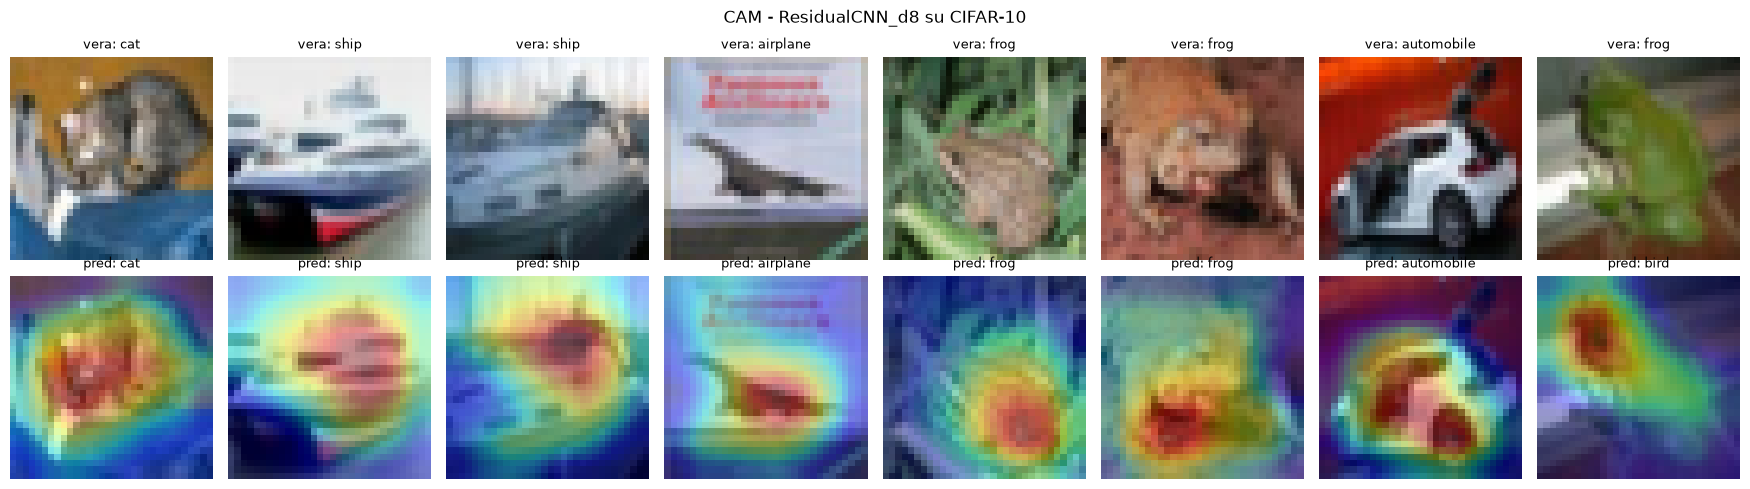

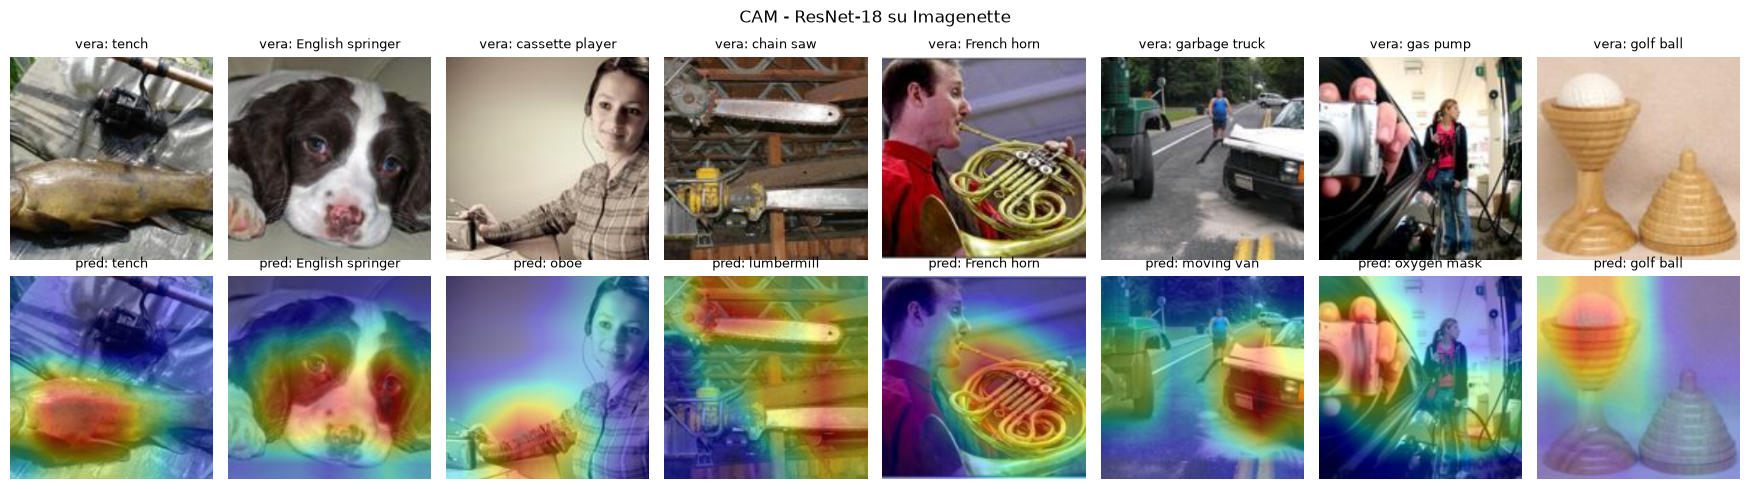

In [13]:
config_23 = {
    "n_examples": 8,
    "cam_alpha": 0.4,
    "resnet_weights": "IMAGENET1K_V1",
    "imagenette_split": "val",
    "imagenette_size": "160px",
}
n = config_23["n_examples"]

cifar_name = max((k for k in results_13 if k.startswith("ResidualCNN")),
                 key=lambda k: max(results_13[k][1]["val_acc"]))
cifar_model = results_13[cifar_name][0].to(device).eval()
config_23["cifar_model"] = cifar_name

run = wandb.init(project="dla-lab1-es2.3", name="cam", job_type="cam", config=config_23)

ds_cifar_test = get_cifar10(augmentation=False)[2].dataset
images, labels = zip(*[ds_cifar_test[i] for i in range(n)])
cams, preds = compute_cam(cifar_model.feature_maps, cifar_model.fc, torch.stack(images).to(device))
plot_cams(images, [ds_cifar_test.classes[l] for l in labels], cams,
          [ds_cifar_test.classes[p] for p in preds], CIFAR10_MEAN, CIFAR10_STD,
          f"CAM - {cifar_name} su CIFAR-10", config_23["cam_alpha"], run)

weights = getattr(ResNet18_Weights, config_23["resnet_weights"])
preprocess = weights.transforms()
resnet = resnet18(weights=weights).to(device).eval()
resnet_trunk = nn.Sequential(*list(resnet.children())[:-2])

imagenette_kwargs = dict(root="./data", split=config_23["imagenette_split"],
                         size=config_23["imagenette_size"], transform=preprocess)
try:
    ds_imagenette = Imagenette(download=True, **imagenette_kwargs)
except RuntimeError:
    ds_imagenette = Imagenette(download=False, **imagenette_kwargs)

step = len(ds_imagenette) // n
images, labels = zip(*[ds_imagenette[i * step] for i in range(n)])
cams, preds = compute_cam(resnet_trunk, resnet.fc, torch.stack(images).to(device))
plot_cams(images, [ds_imagenette.classes[l][0] for l in labels], cams,
          [weights.meta["categories"][p] for p in preds], preprocess.mean, preprocess.std,
          "CAM - ResNet-18 su Imagenette", config_23["cam_alpha"], run)

run.finish()
